<a href="https://colab.research.google.com/github/rodrigogossi/ic_rodrigogossi_yollov8/blob/main/comparacao_modelos_640_vs_1024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparação de Modelos — YOLOv8 Segmentação — 640px vs 1024px
## Geração de figuras científicas para artigo
**Ambiente:** Google Colab

---
### Instruções
1. Monte o Google Drive (Célula 1)
2. Instale as dependências (Célula 2)
3. **Edite os caminhos na Célula 3**
4. Execute todas as células em sequência


### Célula 1 — Montar Google Drive


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Célula 2 — Instalação de dependências


In [2]:
!pip install -U pandas numpy matplotlib scipy scikit-learn


### Célula 3 — Imports


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
import scipy.stats as stats
from sklearn.metrics import r2_score, mean_squared_error
from pathlib import Path


### Célula 4 — Configurações ← EDITE AQUI


In [4]:
# CSVs gerados pelo script de cálculo de área
CSV_640  = '/content/drive/MyDrive/ic-yollov8/resultados_area_640/relatorio_validacao_area.csv'
CSV_1024 = '/content/drive/MyDrive/ic-yollov8/resultados_area_1024/relatorio_validacao_area.csv'

# CSVs de métricas do K-Fold (treino)
KFOLD_640  = '/content/drive/MyDrive/ic-yollov8/resultados_640px_2026-03-18/metricas_completas.csv'
KFOLD_1024 = '/content/drive/MyDrive/ic-yollov8/resultados_1024px_2026-03-18/metricas_completas.csv'

# Pasta de saída
SAIDA = Path('/content/drive/MyDrive/ic-yollov8/figuras_artigo')
SAIDA.mkdir(parents=True, exist_ok=True)

# Paleta de cores
COR_640   = '#2563EB'  # azul
COR_1024  = '#DC2626'  # vermelho
COR_IDEAL = '#16A34A'  # verde

print('✅ Configurações definidas')


✅ Configurações definidas


### Célula 5 — Carregar dados


In [5]:
df_640  = pd.read_csv(CSV_640)
df_1024 = pd.read_csv(CSV_1024)

kf_640  = pd.read_csv(KFOLD_640).rename(columns={'Unnamed: 0': 'split'})
kf_1024 = pd.read_csv(KFOLD_1024).rename(columns={'Unnamed: 0': 'split'})

# Remove linhas de média/desvio
kf_640  = kf_640[~kf_640['split'].isin(['Média Geral', 'Desvio Padrão Geral'])]
kf_1024 = kf_1024[~kf_1024['split'].isin(['Média Geral', 'Desvio Padrão Geral'])]

# Garante tipos numéricos
for col in ['mAP50', 'mAP50-95', 'Precision', 'Recall']:
    kf_640[col]  = pd.to_numeric(kf_640[col],  errors='coerce')
    kf_1024[col] = pd.to_numeric(kf_1024[col], errors='coerce')

print(f'✅ 640px  — {len(df_640)} amostras de área  |  {len(kf_640)} folds de treino')
print(f'✅ 1024px — {len(df_1024)} amostras de área  |  {len(kf_1024)} folds de treino')


✅ 640px  — 542 amostras de área  |  15 folds de treino
✅ 1024px — 542 amostras de área  |  15 folds de treino


### Célula 6 — Calcular métricas consolidadas


In [6]:
def metricas(df):
    real   = df['Real_mm2'].values
    pred   = df['IA_mm2'].values
    r2     = r2_score(real, pred)
    rmse   = np.sqrt(mean_squared_error(real, pred))
    mae    = np.mean(np.abs(real - pred))
    mape   = df['Erro_Perc'].mean()
    bias   = np.mean(pred - real)
    sd     = np.std(pred - real, ddof=1)
    pr, pp = stats.pearsonr(real, pred)
    return dict(r2=r2, rmse=rmse, mae=mae, mape=mape,
                bias=bias, sd=sd, loa_sup=bias+1.96*sd,
                loa_inf=bias-1.96*sd, pearson_r=pr, pearson_p=pp)

m640  = metricas(df_640)
m1024 = metricas(df_1024)

print('\n📊 MÉTRICAS CONSOLIDADAS')
print(f"{'Métrica':<15} {'640px':>10} {'1024px':>10} {'Vencedor':>10}")
print('─'*48)
metricas_lista = [
    ('R²',        m640['r2'],         m1024['r2'],         True),
    ('RMSE mm²',  m640['rmse'],       m1024['rmse'],       False),
    ('MAE mm²',   m640['mae'],        m1024['mae'],        False),
    ('MAPE %',    m640['mape'],       m1024['mape'],       False),
    ('Pearson r', m640['pearson_r'],  m1024['pearson_r'],  True),
    ('Bias mm²',  m640['bias'],       m1024['bias'],       None),
]
for nome, v640, v1024, maior_melhor in metricas_lista:
    if maior_melhor is True:
        venc = '1024px ✅' if v1024 > v640 else '640px ✅'
    elif maior_melhor is False:
        venc = '1024px ✅' if v1024 < v640 else '640px ✅'
    else:
        venc = '—'
    print(f'{nome:<15} {v640:>10.4f} {v1024:>10.4f} {venc:>10}')



📊 MÉTRICAS CONSOLIDADAS
Métrica              640px     1024px   Vencedor
────────────────────────────────────────────────
R²                  0.9984     0.9984   1024px ✅
RMSE mm²           60.8495    60.4465   1024px ✅
MAE mm²            34.6302    32.9274   1024px ✅
MAPE %              6.9726     5.7847   1024px ✅
Pearson r           0.9992     0.9992   1024px ✅
Bias mm²            4.5349     5.4712          —


### Célula 7 — Figura 1: Dispersão Real vs IA


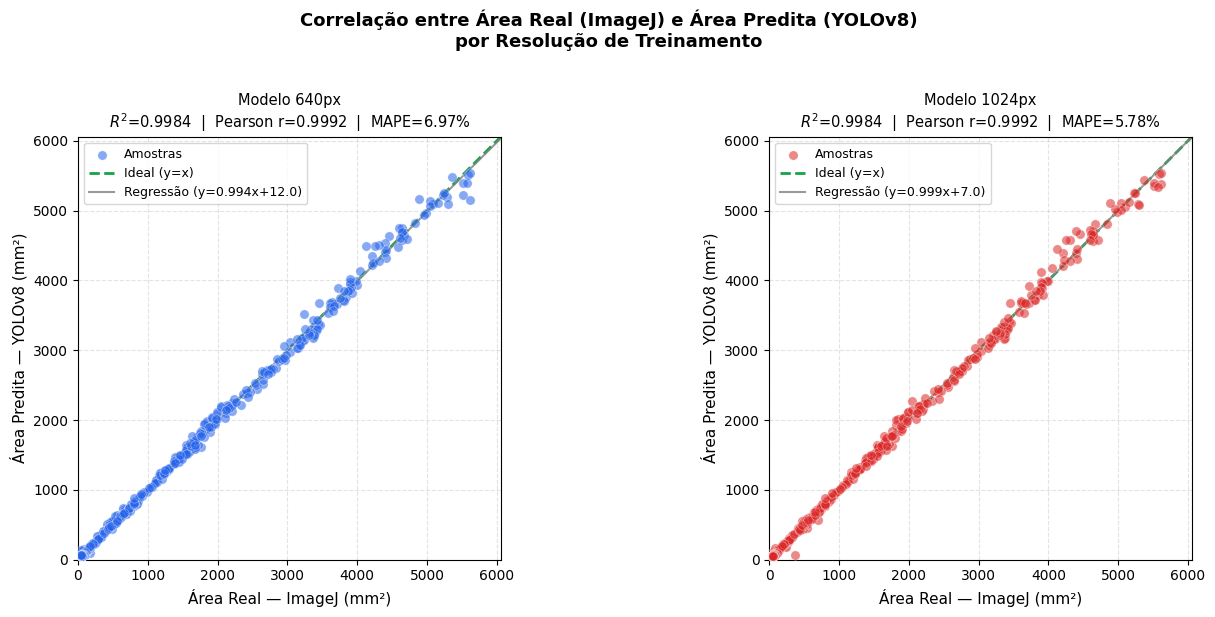

✅ Figura 1 salva: fig1_dispersao_comparativa.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Correlação entre Área Real (ImageJ) e Área Predita (YOLOv8)\npor Resolução de Treinamento',
             fontsize=13, fontweight='bold', y=1.02)

for ax, df, m, cor, titulo in [
    (axes[0], df_640,  m640,  COR_640,  'Modelo 640px'),
    (axes[1], df_1024, m1024, COR_1024, 'Modelo 1024px'),
]:
    real = df['Real_mm2'].values
    pred = df['IA_mm2'].values
    lim  = max(real.max(), pred.max()) * 1.08

    ax.scatter(real, pred, alpha=0.55, color=cor, edgecolors='white',
               linewidths=0.4, s=45, label='Amostras', zorder=3)
    ax.plot([0, lim], [0, lim], color=COR_IDEAL, linestyle='--',
            linewidth=2, label='Ideal (y=x)', zorder=2)
    slope, intercept = np.polyfit(real, pred, 1)
    x_reg = np.linspace(0, lim, 200)
    ax.plot(x_reg, slope*x_reg + intercept, color='gray',
            linewidth=1.5, linestyle='-', alpha=0.8,
            label=f'Regressão (y={slope:.3f}x{intercept:+.1f})', zorder=2)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel('Área Real — ImageJ (mm²)', fontsize=11)
    ax.set_ylabel('Área Predita — YOLOv8 (mm²)', fontsize=11)
    ax.set_title(f'{titulo}\n$R^2$={m["r2"]:.4f}  |  Pearson r={m["pearson_r"]:.4f}  |  MAPE={m["mape"]:.2f}%', fontsize=10.5)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.set_aspect('equal')

plt.tight_layout()
p = SAIDA / 'fig1_dispersao_comparativa.png'
plt.savefig(p, dpi=300, bbox_inches='tight')
plt.show()
print(f'✅ Figura 1 salva: {p.name}')


### Célula 8 — Figura 2: Bland-Altman


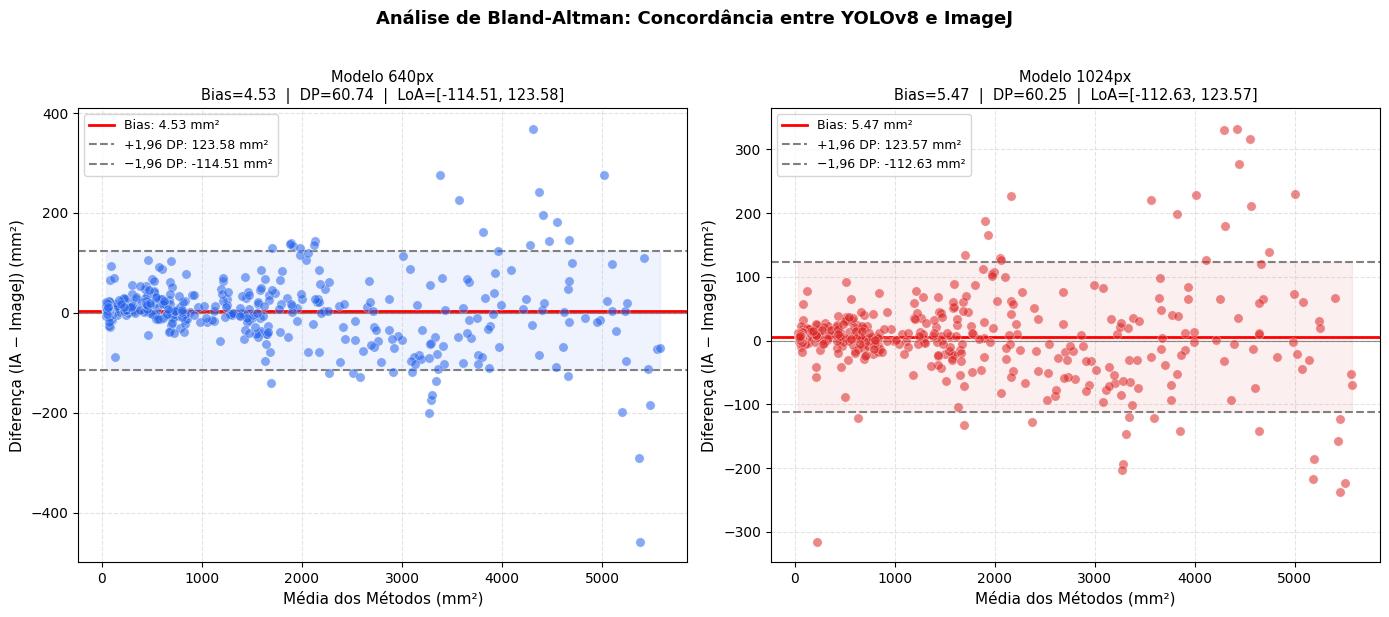

✅ Figura 2 salva: fig2_bland_altman_comparativo.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Análise de Bland-Altman: Concordância entre YOLOv8 e ImageJ',
             fontsize=13, fontweight='bold', y=1.02)

for ax, df, m, cor, titulo in [
    (axes[0], df_640,  m640,  COR_640,  'Modelo 640px'),
    (axes[1], df_1024, m1024, COR_1024, 'Modelo 1024px'),
]:
    media = (df['Real_mm2'] + df['IA_mm2']) / 2
    diff  = df['IA_mm2'] - df['Real_mm2']
    ax.scatter(media, diff, alpha=0.55, color=cor, edgecolors='white', linewidths=0.4, s=45, zorder=3)
    ax.axhline(m['bias'],    color='red',  linestyle='-',  linewidth=2.0, label=f'Bias: {m["bias"]:.2f} mm²', zorder=2)
    ax.axhline(m['loa_sup'], color='gray', linestyle='--', linewidth=1.5, label=f'+1,96 DP: {m["loa_sup"]:.2f} mm²', zorder=2)
    ax.axhline(m['loa_inf'], color='gray', linestyle='--', linewidth=1.5, label=f'−1,96 DP: {m["loa_inf"]:.2f} mm²', zorder=2)
    ax.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.4)
    ax.fill_between([media.min(), media.max()], m['loa_inf'], m['loa_sup'], alpha=0.07, color=cor)
    ax.set_xlabel('Média dos Métodos (mm²)', fontsize=11)
    ax.set_ylabel('Diferença (IA − ImageJ) (mm²)', fontsize=11)
    ax.set_title(f'{titulo}\nBias={m["bias"]:.2f}  |  DP={m["sd"]:.2f}  |  LoA=[{m["loa_inf"]:.2f}, {m["loa_sup"]:.2f}]', fontsize=10.5)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.35)

plt.tight_layout()
p = SAIDA / 'fig2_bland_altman_comparativo.png'
plt.savefig(p, dpi=300, bbox_inches='tight')
plt.show()
print(f'✅ Figura 2 salva: {p.name}')


### Célula 9 — Figura 3: Distribuição de erros (Violin + Histograma)


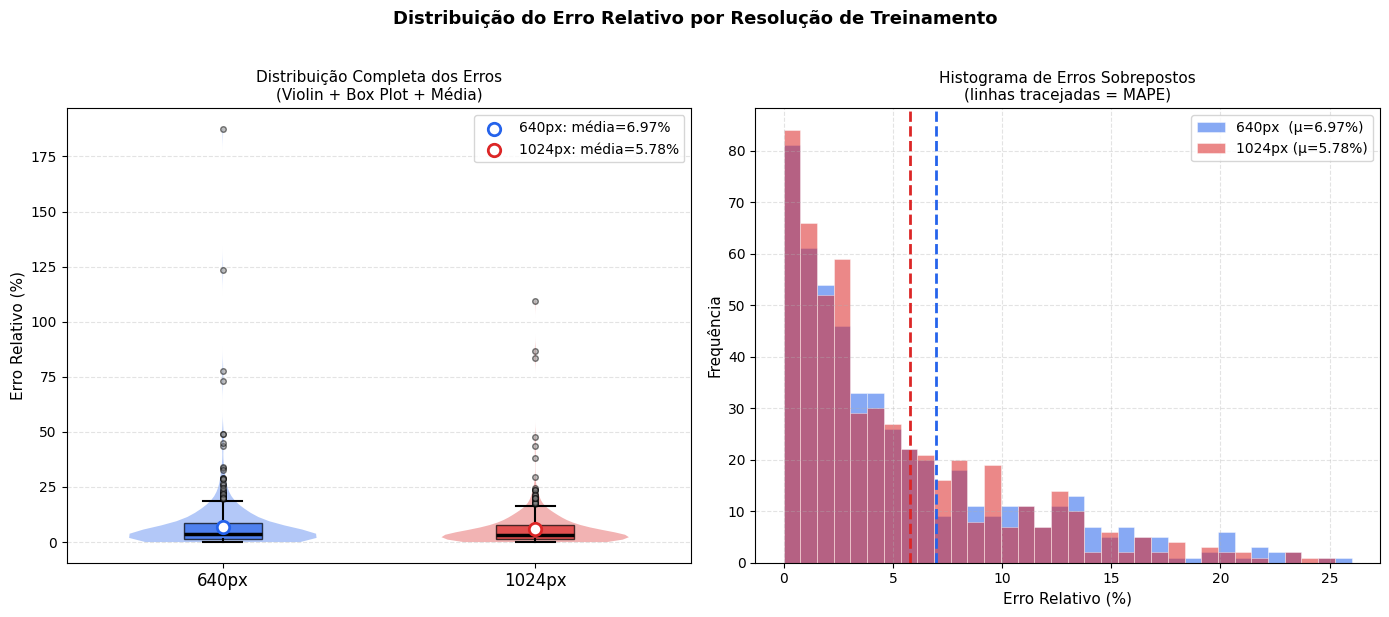

✅ Figura 3 salva: fig3_distribuicao_erros.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribuição do Erro Relativo por Resolução de Treinamento',
             fontsize=13, fontweight='bold', y=1.02)

# Painel esquerdo: Violin + Boxplot
ax = axes[0]
dados  = [df_640['Erro_Perc'].values, df_1024['Erro_Perc'].values]
labels = ['640px', '1024px']
cores  = [COR_640, COR_1024]

parts = ax.violinplot(dados, positions=[1, 2], showmedians=False, showextrema=False, widths=0.6)
for pc, cor in zip(parts['bodies'], cores):
    pc.set_facecolor(cor); pc.set_alpha(0.35)

bp = ax.boxplot(dados, positions=[1, 2], widths=0.25, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2.5),
                whiskerprops=dict(linewidth=1.5), capprops=dict(linewidth=1.5),
                flierprops=dict(marker='o', markersize=4, markerfacecolor='gray', alpha=0.5))
for patch, cor in zip(bp['boxes'], cores):
    patch.set_facecolor(cor); patch.set_alpha(0.7)

for i, (d, cor) in enumerate(zip(dados, cores), 1):
    ax.scatter(i, np.mean(d), color='white', edgecolors=cor, s=80, zorder=5, linewidths=2,
               label=f'{labels[i-1]}: média={np.mean(d):.2f}%')

ax.set_xticks([1, 2]); ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Erro Relativo (%)', fontsize=11)
ax.set_title('Distribuição Completa dos Erros\n(Violin + Box Plot + Média)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, axis='y', linestyle='--', alpha=0.35)

# Painel direito: Histograma
ax2 = axes[1]
bins = np.linspace(0, max(df_640['Erro_Perc'].quantile(0.97), df_1024['Erro_Perc'].quantile(0.97)), 35)
ax2.hist(df_640['Erro_Perc'],  bins=bins, alpha=0.55, color=COR_640,
         label=f'640px  (μ={m640["mape"]:.2f}%)', edgecolor='white', linewidth=0.5)
ax2.hist(df_1024['Erro_Perc'], bins=bins, alpha=0.55, color=COR_1024,
         label=f'1024px (μ={m1024["mape"]:.2f}%)', edgecolor='white', linewidth=0.5)
ax2.axvline(m640['mape'],  color=COR_640,  linestyle='--', linewidth=2)
ax2.axvline(m1024['mape'], color=COR_1024, linestyle='--', linewidth=2)
ax2.set_xlabel('Erro Relativo (%)', fontsize=11)
ax2.set_ylabel('Frequência', fontsize=11)
ax2.set_title('Histograma de Erros Sobrepostos\n(linhas tracejadas = MAPE)', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.35)

plt.tight_layout()
p = SAIDA / 'fig3_distribuicao_erros.png'
plt.savefig(p, dpi=300, bbox_inches='tight')
plt.show()
print(f'✅ Figura 3 salva: {p.name}')


### Célula 10 — Figura 4: Métricas do K-Fold por fold


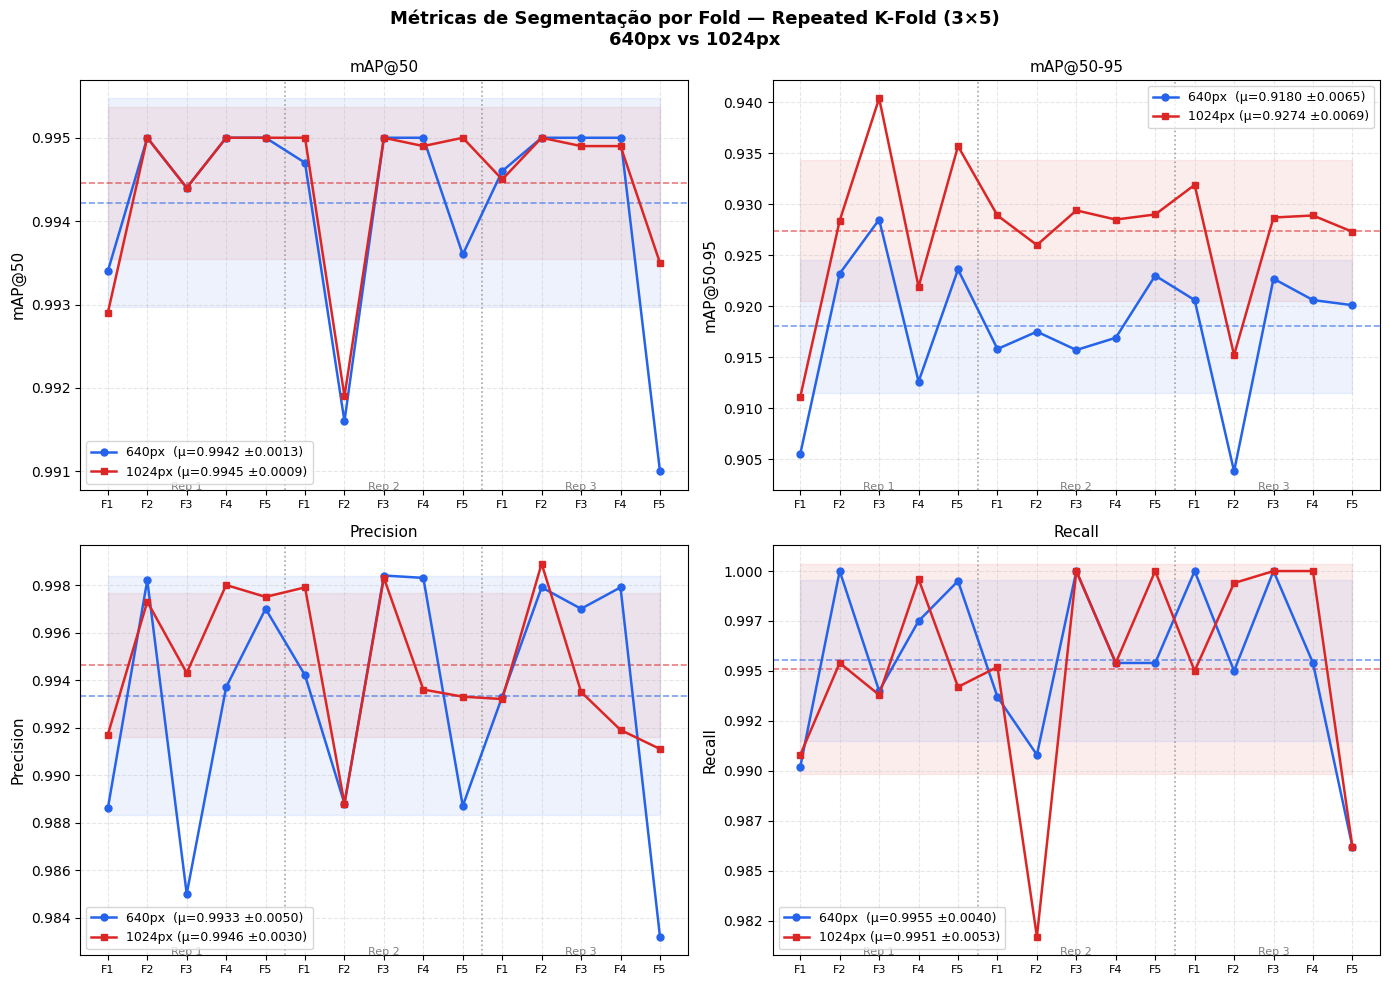

✅ Figura 4 salva: fig4_kfold_metricas_comparativo.png


In [10]:
metricas_kfold = ['mAP50', 'mAP50-95', 'Precision', 'Recall']
titulos_kfold  = ['mAP@50', 'mAP@50-95', 'Precision', 'Recall']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Métricas de Segmentação por Fold — Repeated K-Fold (3×5)\n640px vs 1024px',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

for ax, metrica, titulo in zip(axes, metricas_kfold, titulos_kfold):
    v640  = kf_640[metrica].values
    v1024 = kf_1024[metrica].values
    x     = np.arange(len(v640))

    ax.plot(x, v640,  'o-', color=COR_640,  linewidth=1.8, markersize=5,
            label=f'640px  (μ={v640.mean():.4f} ±{v640.std():.4f})', zorder=3)
    ax.plot(x, v1024, 's-', color=COR_1024, linewidth=1.8, markersize=5,
            label=f'1024px (μ={v1024.mean():.4f} ±{v1024.std():.4f})', zorder=3)

    ax.axhline(v640.mean(),  color=COR_640,  linestyle='--', linewidth=1.2, alpha=0.6)
    ax.axhline(v1024.mean(), color=COR_1024, linestyle='--', linewidth=1.2, alpha=0.6)
    ax.fill_between(x, v640.mean()-v640.std(),   v640.mean()+v640.std(),   alpha=0.08, color=COR_640)
    ax.fill_between(x, v1024.mean()-v1024.std(), v1024.mean()+v1024.std(), alpha=0.08, color=COR_1024)

    for rep_break in [4.5, 9.5]:
        ax.axvline(rep_break, color='gray', linestyle=':', linewidth=1.2, alpha=0.7)
    for rx, label in [(2, 'Rep 1'), (7, 'Rep 2'), (12, 'Rep 3')]:
        ax.text(rx, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 0.93,
                label, ha='center', fontsize=8, color='gray')

    ax.set_xticks(x)
    ax.set_xticklabels([f'F{i%5+1}' for i in range(15)], fontsize=8)
    ax.set_ylabel(titulo, fontsize=11)
    ax.set_title(titulo, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

plt.tight_layout()
p = SAIDA / 'fig4_kfold_metricas_comparativo.png'
plt.savefig(p, dpi=300, bbox_inches='tight')
plt.show()
print(f'✅ Figura 4 salva: {p.name}')


### Célula 11 — Figura 5: Radar Chart


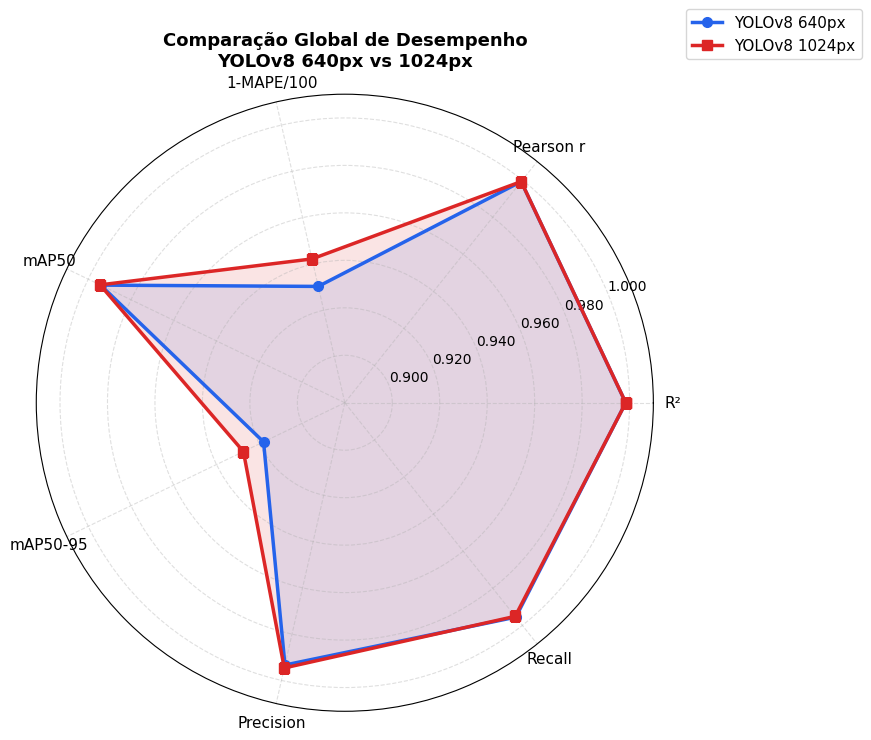

✅ Figura 5 salva: fig5_radar_comparativo.png


In [11]:
metricas_radar = {
    'R²'         : (m640['r2'],                  m1024['r2']),
    'Pearson r'  : (m640['pearson_r'],            m1024['pearson_r']),
    '1-MAPE/100' : (1-m640['mape']/100,           1-m1024['mape']/100),
    'mAP50'      : (kf_640['mAP50'].mean(),       kf_1024['mAP50'].mean()),
    'mAP50-95'   : (kf_640['mAP50-95'].mean(),    kf_1024['mAP50-95'].mean()),
    'Precision'  : (kf_640['Precision'].mean(),   kf_1024['Precision'].mean()),
    'Recall'     : (kf_640['Recall'].mean(),      kf_1024['Recall'].mean()),
}

labels_radar = list(metricas_radar.keys())
vals_640  = [v[0] for v in metricas_radar.values()]
vals_1024 = [v[1] for v in metricas_radar.values()]

N = len(labels_radar)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]
vals_640  += vals_640[:1]
vals_1024 += vals_1024[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
ax.plot(angles, vals_640,  'o-', color=COR_640,  linewidth=2.5, markersize=7, label='YOLOv8 640px',  zorder=3)
ax.fill(angles, vals_640,  alpha=0.12, color=COR_640)
ax.plot(angles, vals_1024, 's-', color=COR_1024, linewidth=2.5, markersize=7, label='YOLOv8 1024px', zorder=3)
ax.fill(angles, vals_1024, alpha=0.12, color=COR_1024)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=11)
ax.set_ylim(0.88, 1.01)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
ax.set_title('Comparação Global de Desempenho\nYOLOv8 640px vs 1024px',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
p = SAIDA / 'fig5_radar_comparativo.png'
plt.savefig(p, dpi=300, bbox_inches='tight')
plt.show()
print(f'✅ Figura 5 salva: {p.name}')


### Célula 12 — Figura 6: Tabela comparativa publicável


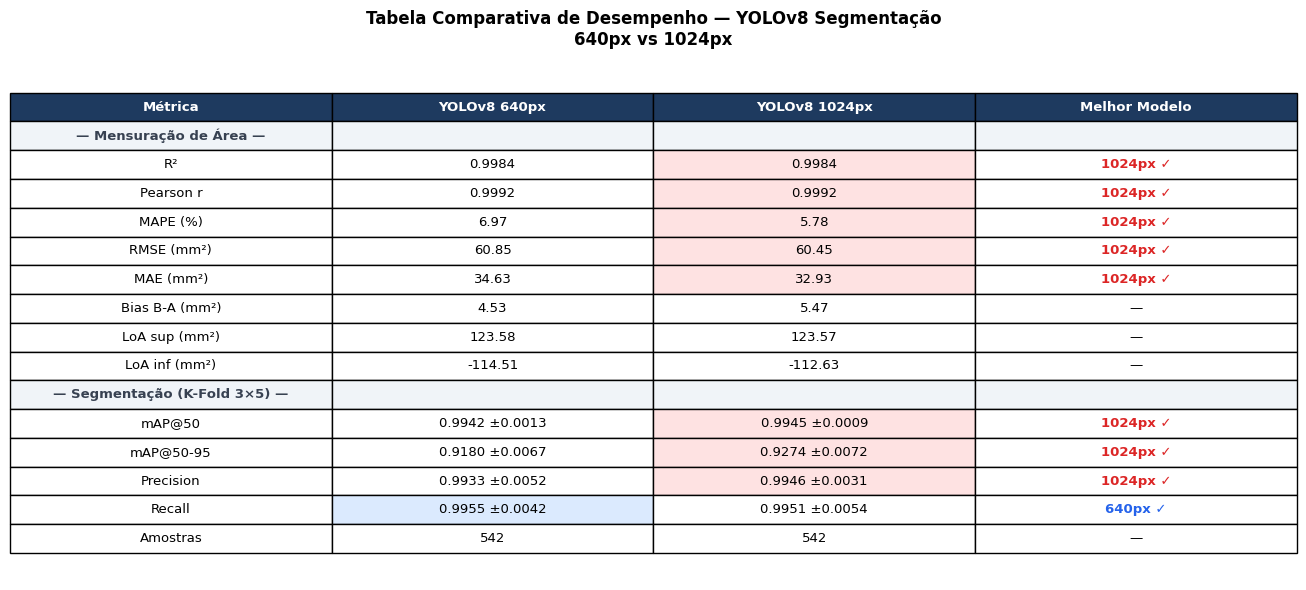

✅ Figura 6 salva: fig6_tabela_comparativa.png


In [12]:
def venc(v640, v1024, maior_melhor=True):
    if maior_melhor:
        return '640px ✓' if v640 > v1024 else '1024px ✓'
    else:
        return '640px ✓' if v640 < v1024 else '1024px ✓'

linhas = [
    ['— Mensuração de Área —', '', '', ''],
    ['R²',             f'{m640["r2"]:.4f}',          f'{m1024["r2"]:.4f}',          venc(m640['r2'],        m1024['r2'])],
    ['Pearson r',      f'{m640["pearson_r"]:.4f}',    f'{m1024["pearson_r"]:.4f}',    venc(m640['pearson_r'], m1024['pearson_r'])],
    ['MAPE (%)',       f'{m640["mape"]:.2f}',          f'{m1024["mape"]:.2f}',          venc(m640['mape'],      m1024['mape'], False)],
    ['RMSE (mm²)',     f'{m640["rmse"]:.2f}',          f'{m1024["rmse"]:.2f}',          venc(m640['rmse'],      m1024['rmse'], False)],
    ['MAE (mm²)',      f'{m640["mae"]:.2f}',           f'{m1024["mae"]:.2f}',           venc(m640['mae'],       m1024['mae'],  False)],
    ['Bias B-A (mm²)', f'{m640["bias"]:.2f}',          f'{m1024["bias"]:.2f}',          '—'],
    ['LoA sup (mm²)',  f'{m640["loa_sup"]:.2f}',       f'{m1024["loa_sup"]:.2f}',       '—'],
    ['LoA inf (mm²)',  f'{m640["loa_inf"]:.2f}',       f'{m1024["loa_inf"]:.2f}',       '—'],
    ['— Segmentação (K-Fold 3×5) —', '', '', ''],
    ['mAP@50',    f'{kf_640["mAP50"].mean():.4f} ±{kf_640["mAP50"].std():.4f}',       f'{kf_1024["mAP50"].mean():.4f} ±{kf_1024["mAP50"].std():.4f}',       venc(kf_640['mAP50'].mean(),    kf_1024['mAP50'].mean())],
    ['mAP@50-95', f'{kf_640["mAP50-95"].mean():.4f} ±{kf_640["mAP50-95"].std():.4f}', f'{kf_1024["mAP50-95"].mean():.4f} ±{kf_1024["mAP50-95"].std():.4f}', venc(kf_640['mAP50-95'].mean(), kf_1024['mAP50-95'].mean())],
    ['Precision', f'{kf_640["Precision"].mean():.4f} ±{kf_640["Precision"].std():.4f}', f'{kf_1024["Precision"].mean():.4f} ±{kf_1024["Precision"].std():.4f}', venc(kf_640['Precision'].mean(), kf_1024['Precision'].mean())],
    ['Recall',    f'{kf_640["Recall"].mean():.4f} ±{kf_640["Recall"].std():.4f}',       f'{kf_1024["Recall"].mean():.4f} ±{kf_1024["Recall"].std():.4f}',       venc(kf_640['Recall'].mean(),    kf_1024['Recall'].mean())],
    ['Amostras', '542', '542', '—'],
]

fig, ax = plt.subplots(figsize=(13, 6))
ax.axis('off')
tabela = ax.table(cellText=linhas,
                  colLabels=['Métrica', 'YOLOv8 640px', 'YOLOv8 1024px', 'Melhor Modelo'],
                  loc='center', cellLoc='center')
tabela.auto_set_font_size(False)
tabela.set_fontsize(9.5)
tabela.scale(1.15, 1.55)

for j in range(4):
    tabela[0, j].set_facecolor('#1E3A5F')
    tabela[0, j].set_text_props(color='white', fontweight='bold')

for i, row in enumerate(linhas, 1):
    if row[0].startswith('—'):
        for j in range(4):
            tabela[i, j].set_facecolor('#F0F4F8')
            tabela[i, j].set_text_props(fontweight='bold', color='#374151')

for i, row in enumerate(linhas, 1):
    if '640px ✓' in row[3]:
        tabela[i, 1].set_facecolor('#DBEAFE')
        tabela[i, 3].set_text_props(color=COR_640, fontweight='bold')
    elif '1024px ✓' in row[3]:
        tabela[i, 2].set_facecolor('#FEE2E2')
        tabela[i, 3].set_text_props(color=COR_1024, fontweight='bold')

ax.set_title('Tabela Comparativa de Desempenho — YOLOv8 Segmentação\n640px vs 1024px',
             fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
p = SAIDA / 'fig6_tabela_comparativa.png'
plt.savefig(p, dpi=300, bbox_inches='tight')
plt.show()
print(f'✅ Figura 6 salva: {p.name}')


### Célula 13 — Veredicto final: modelo campeão


In [13]:
print('\n' + '='*60)
print('  VEREDICTO FINAL — MODELO CAMPEÃO POR CATEGORIA')
print('='*60)

placar_640 = 0
placar_1024 = 0

comparacoes = [
    ('R²',        m640['r2'],               m1024['r2'],               True),
    ('MAPE',      m640['mape'],             m1024['mape'],             False),
    ('RMSE',      m640['rmse'],             m1024['rmse'],             False),
    ('MAE',       m640['mae'],              m1024['mae'],              False),
    ('mAP50',     kf_640['mAP50'].mean(),   kf_1024['mAP50'].mean(),   True),
    ('mAP50-95',  kf_640['mAP50-95'].mean(),kf_1024['mAP50-95'].mean(),True),
    ('Precision', kf_640['Precision'].mean(),kf_1024['Precision'].mean(),True),
    ('Recall',    kf_640['Recall'].mean(),  kf_1024['Recall'].mean(),  True),
]

for nome, v640, v1024, maior_melhor in comparacoes:
    vencedor = ('1024px' if v1024 > v640 else '640px') if maior_melhor else ('1024px' if v1024 < v640 else '640px')
    if vencedor == '640px': placar_640  += 1
    else:                   placar_1024 += 1
    emoji = '🔵' if vencedor == '640px' else '🔴'
    print(f'  {emoji} {nome:<12}: {vencedor}  ({v640:.4f} vs {v1024:.4f})')

campeao = '1024px' if placar_1024 > placar_640 else '640px'
print(f'\n  📊 Placar final:')
print(f'     🔵 640px  — {placar_640} vitórias')
print(f'     🔴 1024px — {placar_1024} vitórias')
print(f'\n  🏆 MODELO CAMPEÃO GERAL: YOLOv8 {campeao}')
print('='*60)
print(f'\n📁 Figuras salvas em: {SAIDA}')
for fig_name in ['fig1_dispersao_comparativa.png', 'fig2_bland_altman_comparativo.png',
                 'fig3_distribuicao_erros.png', 'fig4_kfold_metricas_comparativo.png',
                 'fig5_radar_comparativo.png', 'fig6_tabela_comparativa.png']:
    print(f'   📊 {fig_name}')



  VEREDICTO FINAL — MODELO CAMPEÃO POR CATEGORIA
  🔴 R²          : 1024px  (0.9984 vs 0.9984)
  🔴 MAPE        : 1024px  (6.9726 vs 5.7847)
  🔴 RMSE        : 1024px  (60.8495 vs 60.4465)
  🔴 MAE         : 1024px  (34.6302 vs 32.9274)
  🔴 mAP50       : 1024px  (0.9942 vs 0.9945)
  🔴 mAP50-95    : 1024px  (0.9180 vs 0.9274)
  🔴 Precision   : 1024px  (0.9933 vs 0.9946)
  🔵 Recall      : 640px  (0.9955 vs 0.9951)

  📊 Placar final:
     🔵 640px  — 1 vitórias
     🔴 1024px — 7 vitórias

  🏆 MODELO CAMPEÃO GERAL: YOLOv8 1024px

📁 Figuras salvas em: /content/drive/MyDrive/ic-yollov8/figuras_artigo
   📊 fig1_dispersao_comparativa.png
   📊 fig2_bland_altman_comparativo.png
   📊 fig3_distribuicao_erros.png
   📊 fig4_kfold_metricas_comparativo.png
   📊 fig5_radar_comparativo.png
   📊 fig6_tabela_comparativa.png


---
### Célula 14 — Análise do melhor modelo individual (640px e 1024px)


In [14]:
# ── Identifica o melhor fold de cada resolução ──────────────────────────────
# Critério: maior mAP50, desempate por mAP50-95

idx_best_640  = kf_640['mAP50'].idxmax()
idx_best_1024 = kf_1024['mAP50'].idxmax()

best_640  = kf_640.loc[idx_best_640]
best_1024 = kf_1024.loc[idx_best_1024]

# Pior fold (maior variação em relação à média)
kf_640['dist_media']  = abs(kf_640['mAP50']  - kf_640['mAP50'].mean())
kf_1024['dist_media'] = abs(kf_1024['mAP50'] - kf_1024['mAP50'].mean())
worst_640  = kf_640.loc[kf_640['dist_media'].idxmax()]
worst_1024 = kf_1024.loc[kf_1024['dist_media'].idxmax()]

print('='*65)
print('  ANÁLISE DOS MODELOS INDIVIDUAIS')
print('='*65)

print(f'\n🔵 640px — Melhor fold : {best_640["split"]}')
print(f'   mAP50={best_640["mAP50"]:.4f}  mAP50-95={best_640["mAP50-95"]:.4f}  '
      f'Precision={best_640["Precision"]:.4f}  Recall={best_640["Recall"]:.4f}')
print(f'   Pior fold  : {worst_640["split"]}')
print(f'   mAP50={worst_640["mAP50"]:.4f}  mAP50-95={worst_640["mAP50-95"]:.4f}  '
      f'Precision={worst_640["Precision"]:.4f}  Recall={worst_640["Recall"]:.4f}')

print(f'\n🔴 1024px — Melhor fold: {best_1024["split"]}')
print(f'   mAP50={best_1024["mAP50"]:.4f}  mAP50-95={best_1024["mAP50-95"]:.4f}  '
      f'Precision={best_1024["Precision"]:.4f}  Recall={best_1024["Recall"]:.4f}')
print(f'   Pior fold  : {worst_1024["split"]}')
print(f'   mAP50={worst_1024["mAP50"]:.4f}  mAP50-95={worst_1024["mAP50-95"]:.4f}  '
      f'Precision={worst_1024["Precision"]:.4f}  Recall={worst_1024["Recall"]:.4f}')

# Melhor modelo absoluto entre todos os 30
kf_all = pd.concat([
    kf_640.assign(resolucao='640px'),
    kf_1024.assign(resolucao='1024px')
], ignore_index=True)

idx_abs = kf_all['mAP50'].idxmax()
melhor_abs = kf_all.loc[idx_abs]

print(f'\n🏆 MELHOR MODELO ABSOLUTO (entre todos os 30 folds):')
print(f'   {melhor_abs["resolucao"]} — {melhor_abs["split"]}')
print(f'   mAP50={melhor_abs["mAP50"]:.4f}  mAP50-95={melhor_abs["mAP50-95"]:.4f}  '
      f'Precision={melhor_abs["Precision"]:.4f}  Recall={melhor_abs["Recall"]:.4f}')
print('='*65)

# Estatísticas por repetição
print('\n📊 Média mAP50 por repetição:')
for res, kf in [('640px', kf_640), ('1024px', kf_1024)]:
    for rep in ['rep1', 'rep2', 'rep3']:
        subset = kf[kf['split'].str.startswith(rep)]
        print(f'   {res} {rep}: {subset["mAP50"].mean():.4f} ±{subset["mAP50"].std():.4f}')


  ANÁLISE DOS MODELOS INDIVIDUAIS

🔵 640px — Melhor fold : rep1_fold2
   mAP50=0.9950  mAP50-95=0.9232  Precision=0.9982  Recall=1.0000
   Pior fold  : rep3_fold5
   mAP50=0.9910  mAP50-95=0.9201  Precision=0.9832  Recall=0.9862

🔴 1024px — Melhor fold: rep1_fold2
   mAP50=0.9950  mAP50-95=0.9284  Precision=0.9973  Recall=0.9954
   Pior fold  : rep2_fold2
   mAP50=0.9919  mAP50-95=0.9260  Precision=0.9888  Recall=0.9817

🏆 MELHOR MODELO ABSOLUTO (entre todos os 30 folds):
   640px — rep1_fold2
   mAP50=0.9950  mAP50-95=0.9232  Precision=0.9982  Recall=1.0000

📊 Média mAP50 por repetição:
   640px rep1: 0.9946 ±0.0007
   640px rep2: 0.9940 ±0.0014
   640px rep3: 0.9941 ±0.0018
   1024px rep1: 0.9945 ±0.0009
   1024px rep2: 0.9944 ±0.0014
   1024px rep3: 0.9946 ±0.0006


### Célula 15 — Figura 7: mAP50-95 de todos os 30 folds + médias


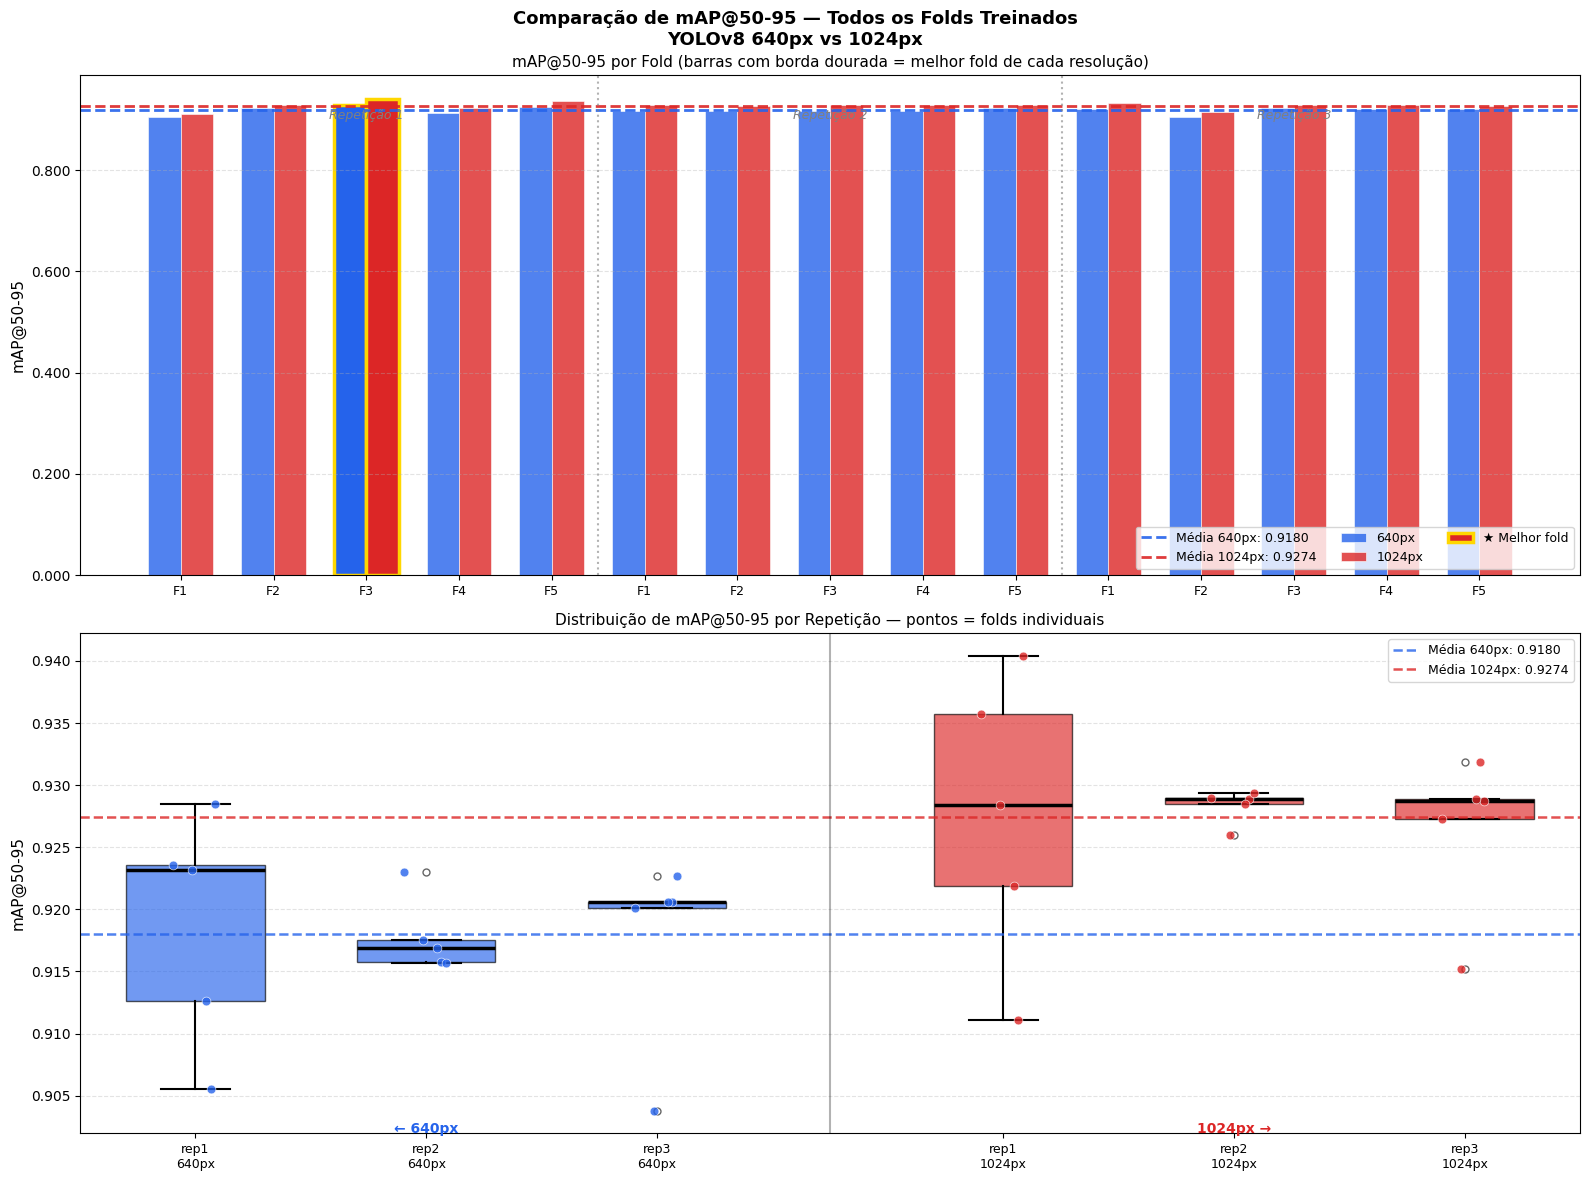

✅ Figura 7 salva: fig7_mAP5095_todos_folds.png


In [15]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('Comparação de mAP@50-95 — Todos os Folds Treinados\nYOLOv8 640px vs 1024px',
             fontsize=13, fontweight='bold')

# ── Painel superior: mAP50-95 todos os folds ──────────────────────────────
ax1 = axes[0]
x   = np.arange(15)
w   = 0.35

bars_640  = ax1.bar(x - w/2, kf_640['mAP50-95'].values,  width=w, color=COR_640,
                    alpha=0.8, label='640px',  edgecolor='white', linewidth=0.5)
bars_1024 = ax1.bar(x + w/2, kf_1024['mAP50-95'].values, width=w, color=COR_1024,
                    alpha=0.8, label='1024px', edgecolor='white', linewidth=0.5)

# Médias gerais
media_640  = kf_640['mAP50-95'].mean()
media_1024 = kf_1024['mAP50-95'].mean()
ax1.axhline(media_640,  color=COR_640,  linestyle='--', linewidth=2,
            label=f'Média 640px: {media_640:.4f}', alpha=0.9)
ax1.axhline(media_1024, color=COR_1024, linestyle='--', linewidth=2,
            label=f'Média 1024px: {media_1024:.4f}', alpha=0.9)

# Destaca melhor de cada resolução
idx_b640  = kf_640['mAP50-95'].idxmax()
idx_b1024 = kf_1024['mAP50-95'].idxmax()
ax1.bar(idx_b640  - w/2, kf_640.loc[idx_b640,  'mAP50-95'], width=w,
        color=COR_640,  edgecolor='gold', linewidth=2.5, alpha=1.0)
ax1.bar(idx_b1024 + w/2, kf_1024.loc[idx_b1024, 'mAP50-95'], width=w,
        color=COR_1024, edgecolor='gold', linewidth=2.5, alpha=1.0,
        label='★ Melhor fold')

# Separadores de repetição
for rep_break in [4.5, 9.5]:
    ax1.axvline(rep_break, color='gray', linestyle=':', linewidth=1.5, alpha=0.6)
for rx, label in [(2, 'Repetição 1'), (7, 'Repetição 2'), (12, 'Repetição 3')]:
    ax1.text(rx, kf_640['mAP50-95'].min() - 0.003, label,
             ha='center', fontsize=9, color='gray', style='italic')

ax1.set_xticks(x)
ax1.set_xticklabels([f'F{i%5+1}' for i in range(15)], fontsize=9)
ax1.set_ylabel('mAP@50-95', fontsize=11)
ax1.set_title('mAP@50-95 por Fold (barras com borda dourada = melhor fold de cada resolução)', fontsize=11)
ax1.legend(fontsize=9, ncol=3)
ax1.grid(True, axis='y', linestyle='--', alpha=0.35)
ax1.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

# ── Painel inferior: boxplot por resolução e repetição ───────────────────
ax2 = axes[1]

# Dados por grupo: rep1_640, rep2_640, rep3_640, rep1_1024, rep2_1024, rep3_1024
grupos = []
labels_box = []
cores_box  = []
posicoes   = []

pos = 1
for res, kf, cor in [('640px', kf_640, COR_640), ('1024px', kf_1024, COR_1024)]:
    for rep in ['rep1', 'rep2', 'rep3']:
        subset = kf[kf['split'].str.startswith(rep)]['mAP50-95'].values
        grupos.append(subset)
        labels_box.append(f'{rep}\n{res}')
        cores_box.append(cor)
        posicoes.append(pos)
        pos += 1
    pos += 0.5  # gap entre resoluções

bp = ax2.boxplot(grupos, positions=posicoes, widths=0.6,
                 patch_artist=True, notch=False,
                 medianprops=dict(color='black', linewidth=2.5),
                 whiskerprops=dict(linewidth=1.5),
                 capprops=dict(linewidth=1.5),
                 flierprops=dict(marker='o', markersize=5, alpha=0.6))

for patch, cor in zip(bp['boxes'], cores_box):
    patch.set_facecolor(cor)
    patch.set_alpha(0.65)

# Pontos individuais sobrepostos
for pos_i, grupo, cor in zip(posicoes, grupos, cores_box):
    jitter = np.random.default_rng(42).uniform(-0.12, 0.12, len(grupo))
    ax2.scatter(pos_i + jitter, grupo, color=cor, edgecolors='white',
                s=40, zorder=5, linewidths=0.5, alpha=0.8)

# Médias gerais por resolução
ax2.axhline(media_640,  color=COR_640,  linestyle='--', linewidth=1.8,
            label=f'Média 640px: {media_640:.4f}', alpha=0.8)
ax2.axhline(media_1024, color=COR_1024, linestyle='--', linewidth=1.8,
            label=f'Média 1024px: {media_1024:.4f}', alpha=0.8)

# Separador entre resoluções
ax2.axvline(3.75, color='black', linestyle='-', linewidth=1.5, alpha=0.3)
ax2.text(2.0,  ax2.get_ylim()[0] if ax2.get_ylim()[0] > 0 else kf_640['mAP50-95'].min()-0.003,
         '← 640px', ha='center', fontsize=10, color=COR_640, fontweight='bold')
ax2.text(5.5,  ax2.get_ylim()[0] if ax2.get_ylim()[0] > 0 else kf_640['mAP50-95'].min()-0.003,
         '1024px →', ha='center', fontsize=10, color=COR_1024, fontweight='bold')

ax2.set_xticks(posicoes)
ax2.set_xticklabels(labels_box, fontsize=9)
ax2.set_ylabel('mAP@50-95', fontsize=11)
ax2.set_title('Distribuição de mAP@50-95 por Repetição — pontos = folds individuais', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, axis='y', linestyle='--', alpha=0.35)
ax2.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

plt.tight_layout()
p = SAIDA / 'fig7_mAP5095_todos_folds.png'
plt.savefig(p, dpi=300, bbox_inches='tight')
plt.show()
print(f'✅ Figura 7 salva: {p.name}')


### Célula 16 — Figura 8: Ranking dos 30 modelos (mAP50 + mAP50-95)


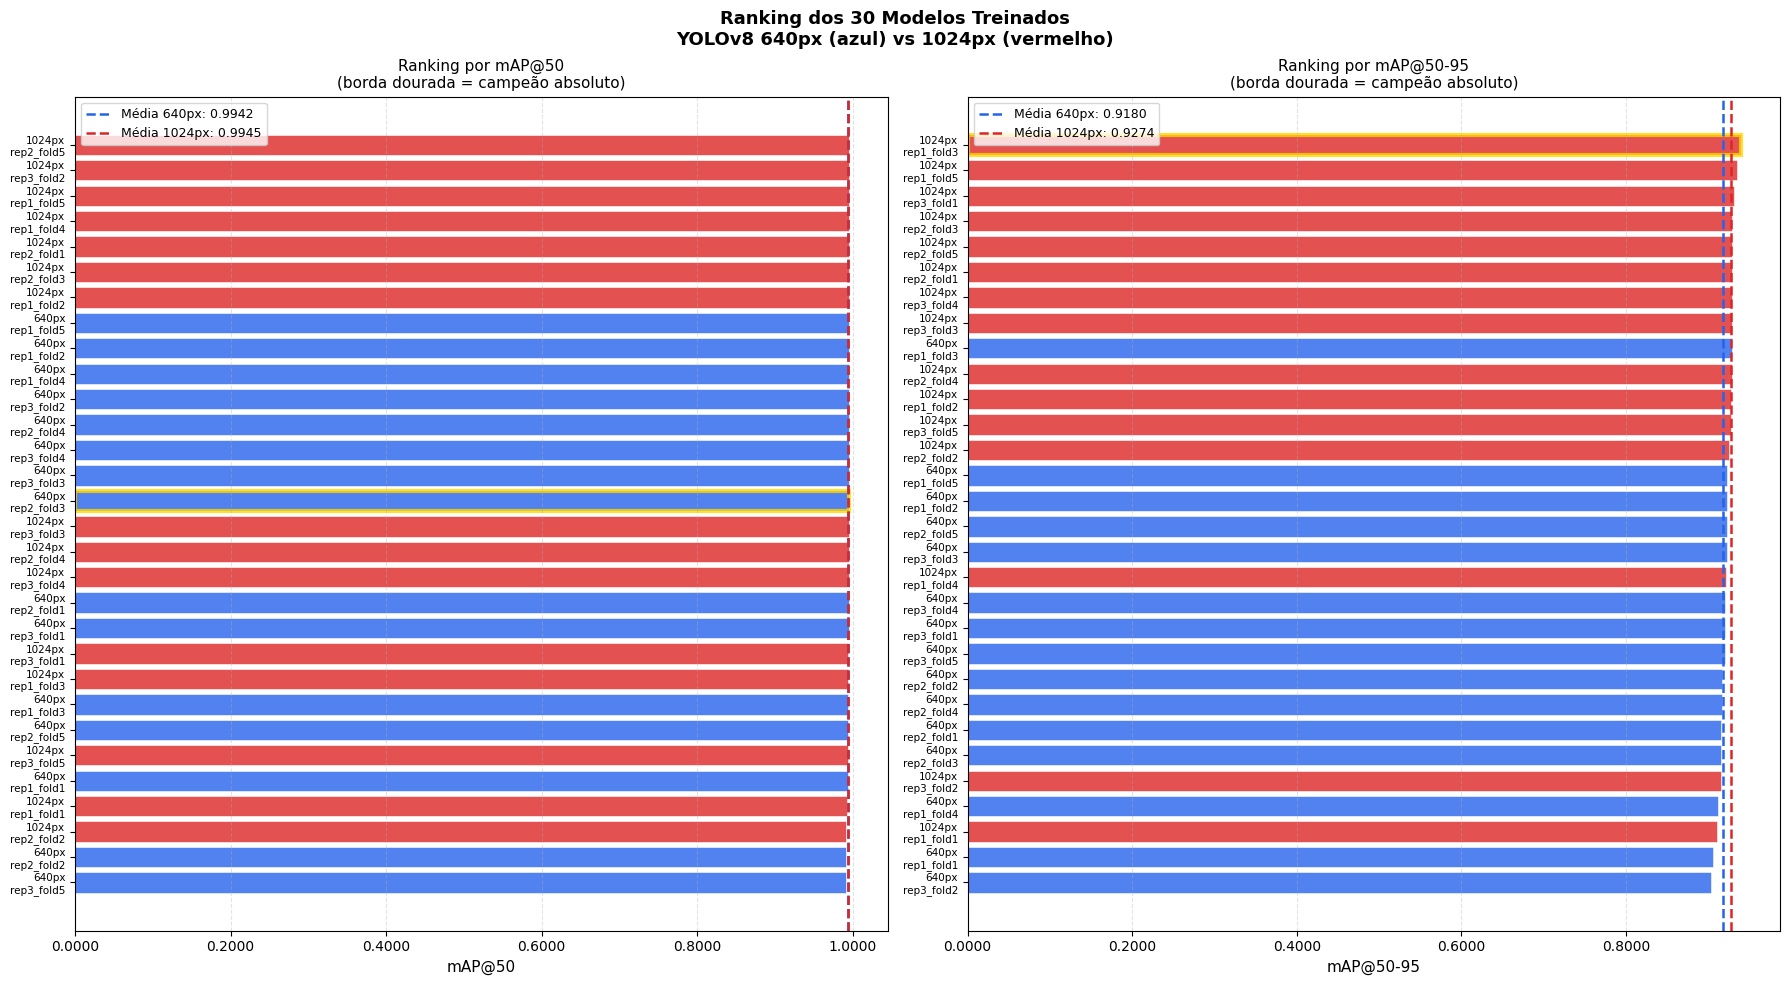

✅ Figura 8 salva: fig8_ranking_30_modelos.png

🏅 Top 5 modelos por mAP50:
#    Resolução  Fold               mAP50   mAP50-95  Precision   Recall
─────────────────────────────────────────────────────────────────
1    1024px     rep1_fold5        0.9950     0.9357     0.9975   0.9942
2    1024px     rep3_fold2        0.9950     0.9152     0.9989   0.9994
3    1024px     rep2_fold1        0.9950     0.9289     0.9979   0.9952
4    1024px     rep2_fold3        0.9950     0.9294     0.9983   1.0000
5    1024px     rep1_fold2        0.9950     0.9284     0.9973   0.9954


In [16]:
# Combina todos os 30 folds ordenados por mAP50
kf_all = pd.concat([
    kf_640.assign(resolucao='640px'),
    kf_1024.assign(resolucao='1024px')
], ignore_index=True)

kf_all = kf_all.sort_values('mAP50', ascending=True).reset_index(drop=True)
cores_rank = [COR_640 if r == '640px' else COR_1024 for r in kf_all['resolucao']]
labels_rank = [f'{row["resolucao"]}\n{row["split"]}' for _, row in kf_all.iterrows()]

fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.suptitle('Ranking dos 30 Modelos Treinados\nYOLOv8 640px (azul) vs 1024px (vermelho)',
             fontsize=13, fontweight='bold')

# Painel esquerdo: mAP50
ax1 = axes[0]
bars = ax1.barh(range(len(kf_all)), kf_all['mAP50'], color=cores_rank,
                alpha=0.8, edgecolor='white', linewidth=0.5)

# Destaca o campeão absoluto
idx_top = kf_all['mAP50'].idxmax()
bars[idx_top].set_edgecolor('gold')
bars[idx_top].set_linewidth(3)

ax1.axvline(kf_640['mAP50'].mean(),  color=COR_640,  linestyle='--',
            linewidth=1.8, label=f'Média 640px: {kf_640["mAP50"].mean():.4f}')
ax1.axvline(kf_1024['mAP50'].mean(), color=COR_1024, linestyle='--',
            linewidth=1.8, label=f'Média 1024px: {kf_1024["mAP50"].mean():.4f}')

ax1.set_yticks(range(len(kf_all)))
ax1.set_yticklabels(labels_rank, fontsize=7.5)
ax1.set_xlabel('mAP@50', fontsize=11)
ax1.set_title('Ranking por mAP@50\n(borda dourada = campeão absoluto)', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, axis='x', linestyle='--', alpha=0.35)
ax1.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f'))

# Painel direito: mAP50-95
kf_all2 = kf_all.sort_values('mAP50-95', ascending=True).reset_index(drop=True)
cores_rank2 = [COR_640 if r == '640px' else COR_1024 for r in kf_all2['resolucao']]
labels_rank2 = [f'{row["resolucao"]}\n{row["split"]}' for _, row in kf_all2.iterrows()]

ax2 = axes[1]
bars2 = ax2.barh(range(len(kf_all2)), kf_all2['mAP50-95'], color=cores_rank2,
                 alpha=0.8, edgecolor='white', linewidth=0.5)

idx_top2 = kf_all2['mAP50-95'].idxmax()
bars2[idx_top2].set_edgecolor('gold')
bars2[idx_top2].set_linewidth(3)

ax2.axvline(kf_640['mAP50-95'].mean(),  color=COR_640,  linestyle='--',
            linewidth=1.8, label=f'Média 640px: {kf_640["mAP50-95"].mean():.4f}')
ax2.axvline(kf_1024['mAP50-95'].mean(), color=COR_1024, linestyle='--',
            linewidth=1.8, label=f'Média 1024px: {kf_1024["mAP50-95"].mean():.4f}')

ax2.set_yticks(range(len(kf_all2)))
ax2.set_yticklabels(labels_rank2, fontsize=7.5)
ax2.set_xlabel('mAP@50-95', fontsize=11)
ax2.set_title('Ranking por mAP@50-95\n(borda dourada = campeão absoluto)', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, axis='x', linestyle='--', alpha=0.35)
ax2.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f'))

plt.tight_layout()
p = SAIDA / 'fig8_ranking_30_modelos.png'
plt.savefig(p, dpi=300, bbox_inches='tight')
plt.show()
print(f'✅ Figura 8 salva: {p.name}')

# Imprime top 5
top5 = kf_all.sort_values('mAP50', ascending=False).head(5)
print('\n🏅 Top 5 modelos por mAP50:')
print(f"{'#':<4} {'Resolução':<10} {'Fold':<15} {'mAP50':>8} {'mAP50-95':>10} {'Precision':>10} {'Recall':>8}")
print('─'*65)
for rank, (_, row) in enumerate(top5.iterrows(), 1):
    print(f"{rank:<4} {row['resolucao']:<10} {row['split']:<15} {row['mAP50']:>8.4f} {row['mAP50-95']:>10.4f} {row['Precision']:>10.4f} {row['Recall']:>8.4f}")
